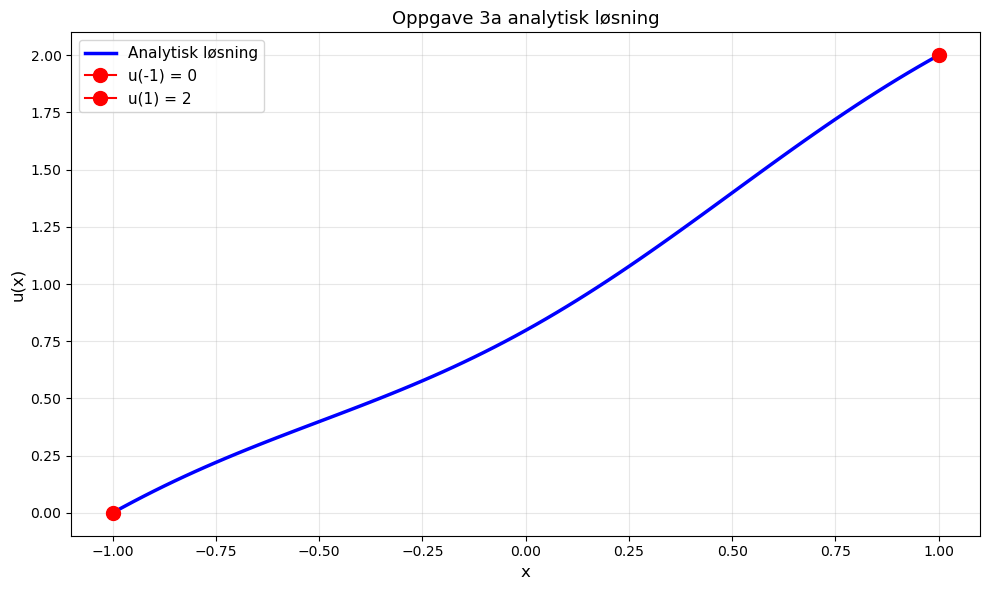

In [19]:
#oppgave 3a#

import numpy as np
import matplotlib.pyplot as plt
import numpy.linalg as la

# u_xx = cos(πx) med randbetingelser

# Generell løsning: u(x) = -cos(πx)/π² + A x + B
# u(-1)=0 → A - B = 1/π²
# u( 1)=2 → A + B = 2 - 1/π²
# → A = 1,   B = 1 - 1/π²

def u_analytisk(x):
    return x + 1 - (np.cos(np.pi * x) + 1) / np.pi**2

u = u_analytisk(x)

plt.figure(figsize=(10, 6))
plt.plot(x, u, 'b-', linewidth=2.5, label='Analytisk løsning')
plt.plot(-1, 0, marker='o', color='r', markersize=10, label='u(-1) = 0')
plt.plot(1, 2, marker='o', color='r', markersize=10, label='u(1) = 2')
plt.title('Oppgave 3a analytisk løsning', fontsize=13)
plt.xlabel('x', fontsize=12)
plt.ylabel('u(x)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

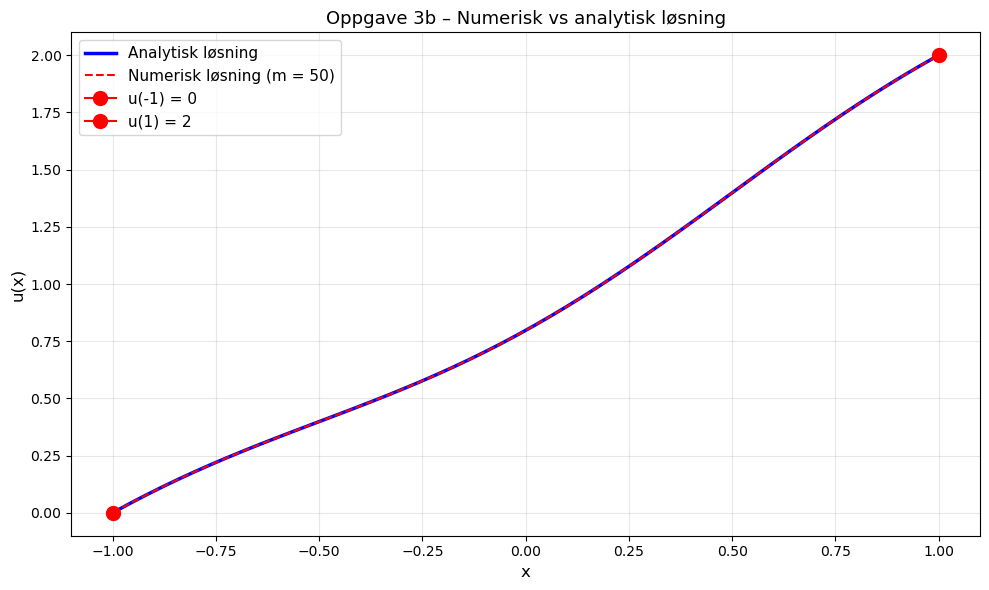

In [20]:
#oppgave 3b#

import numpy as np
import matplotlib.pyplot as plt
import numpy.linalg as la


m = 50
x = np.linspace(-1, 1, m + 2)
h = x[1] - x[0]

u_venstre = 0.0
u_høyre = 2.0

u = u_analytisk(x)
A = np.zeros((m, m))
for i in range(m):
    A[i, i] = -2.0 / h**2
    if i > 0:
        A[i, i-1] = 1.0 / h**2
    if i < m - 1:
        A[i, i+1] = 1.0 / h**2

f_indre = np.cos(np.pi * x[1:-1])
b =  f_indre.copy()             
b[0] -= u_venstre / h**2
b[-1] -= u_høyre / h**2

u_indre = la.solve(A, b)

u_num = np.zeros(m + 2)
u_num[0] = u_venstre
u_num[1:-1] = u_indre
u_num[-1] = u_høyre



plt.figure(figsize=(10, 6))
plt.plot(x, u, 'b-', linewidth=2.5, label='Analytisk løsning')
plt.plot(x, u_num, 'r--', linewidth=1.5, markersize=4, label=f'Numerisk løsning (m = {m})')
plt.plot(-1, 0, marker='o', color='r', markersize=10, label='u(-1) = 0')
plt.plot(1, 2, marker='o', color='r', markersize=10, label='u(1) = 2')
plt.title('Oppgave 3b – Numerisk vs analytisk løsning', fontsize=13)
plt.xlabel('x', fontsize=12)
plt.ylabel('u(x)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()

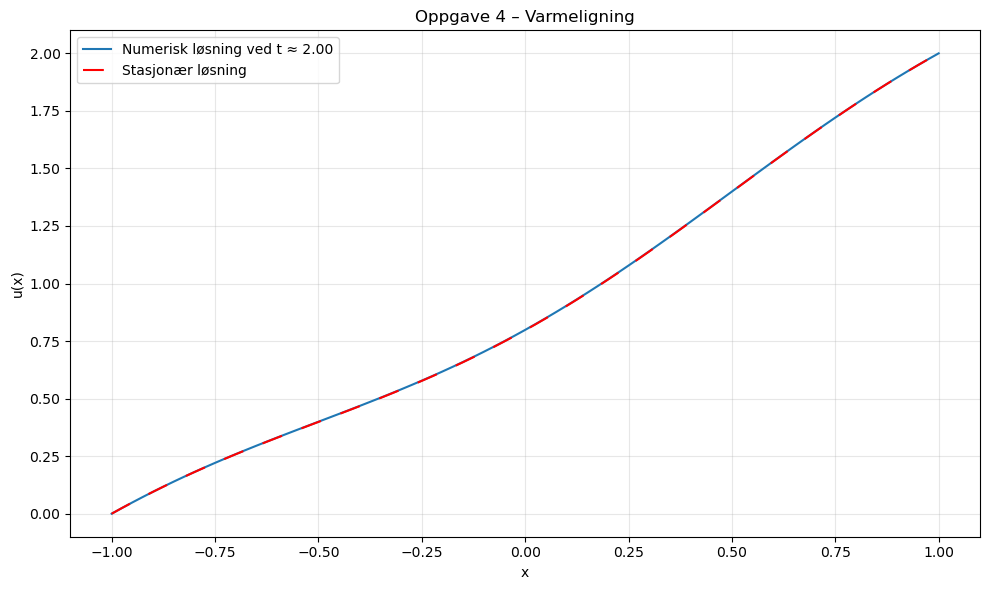

In [21]:
# Oppgave 4

import numpy as np
import matplotlib.pyplot as plt

plt.close("all")


#   u_t = u_xx - cos(πx),    x ∈ (-1,1),  t ≥ 0
#   u(-1,t) = 0,   u(1,t) = 2
#   u(x,0) = 1 + x + 5 sin(πx)
# ------------------------------------------------------------

Nx = 80                     # antall intervaller
x = np.linspace(-1, 1, Nx + 1)
h = x[1] - x[0]             # steglengde i rom

dt = 0.45 * h**2            # r = dt/h² ≈ 0.45 (sikkerhetsmargin, maks 0.5)
T = 2.0                     # ønsket sluttid
Nt = int(T / dt) + 1        # antall tidssteg

u = 1 + x + 5 * np.sin(np.pi * x)
u[0] = 0                    # u(-1,t) = 0
u[-1] = 2                   # u(1,t) = 2

f = np.cos(np.pi * x)      
for n in range(Nt):
    u_ny = u.copy()
    u_ny[1:-1] = u[1:-1] + dt * ((u[2:] - 2*u[1:-1] + u[:-2]) / h**2 - f[1:-1])
    u_ny[0] = 0
    u_ny[-1] = 2
    u = u_ny

# ------------------------------------------------------------
# Plotting
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(x, u, label="Numerisk løsning ved t ≈ {:.2f}".format(Nt*dt))
plt.plot(x, -np.cos(np.pi*x)/(np.pi**2) + x + 1 - 1/(np.pi**2), 
         '--', dashes=(10, 10), color='red', label="Stasjonær løsning")
plt.title("Oppgave 4 – Varmeligning")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()